# In God We Trust

In [1]:
import tensorflow as tf 
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

X  = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
],
              dtype = np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0],
],
             dtype = np.float32)




In [ ]:
model = keras.Sequential([
    
    keras.Input(shape=(X.shape[1],)),
    keras.layers.Dense(units=2, activation="sigmoid"),
    keras.layers.Dense(units=1, activation="sigmoid",)
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])


In [ ]:
history = model.fit(X, y, epochs=500, verbose=0)

prediction = model.predict(X)


In [ ]:
prediction_class = (prediction >= 0.5).astype(int)
for i in range(len(X)):
    print(f"Actual value {y[i]} --> Predicted value {prediction_class[i][0]}")

In [ ]:
print(model.summary())

In [ ]:
w =model.get_weights()
print(f"X0 {w[0]}")
print("--" * 20)
print(f"X1 {w[1]}")
print("--" * 20)
print(f"X2 {w[2]}")
print("--" * 20)
print(f"X3 {w[3]}")

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], color= "blue", label="Accuracy")
plt.plot(history.history["loss"], color="red", label="Loss")

plt.title("Loss and accuracy of XOR")
plt.xlabel("Epochs")
plt.ylabel("Loss and accuracy")

plt.grid(axis="y", linestyle="--", alpha= 0.7)
plt.legend()

plt.show()

In [13]:
data = load_breast_cancer()
X, y, features_name, targets_name= data.data, data.target, data.feature_names, data.target_names

In [14]:
X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify=y)
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)
X_train_scaled.shape

(455, 30)

In [29]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],), name="Input_layer"),
    keras.layers.Dense(units=50, activation="relu", name="Hidden_layer_1"),
    keras.layers.Dense(units=25, activation="relu", name="Hidden_layer_2"),
    keras.layers.Dense(units=1, activation="sigmoid", name="Out_put_layer")
])


early_stop = keras.callbacks.EarlyStopping(
    monitor="accuracy",
    mode= "max",
    patience= 10,
    restore_best_weights=True
)

In [30]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Out_put_layer (Dense)           │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(X_train_scaled,y_train, epochs=1000, batch_size=32, verbose=1, callbacks=[early_stop])

Epoch 1/1000


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6330 - loss: 0.6397   
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9011 - loss: 0.4224 
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9451 - loss: 0.2776 
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9582 - loss: 0.1874 
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9714 - loss: 0.1394 
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9758 - loss: 0.1127 
Epoch 7/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0960 
Epoch 8/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0842 
Epoch 9/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0757 
Epoch 10/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9802 - loss: 0.0685 
Epoch 11/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9846 - loss: 0.0634 
Epoch 12/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [32]:
prediction = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


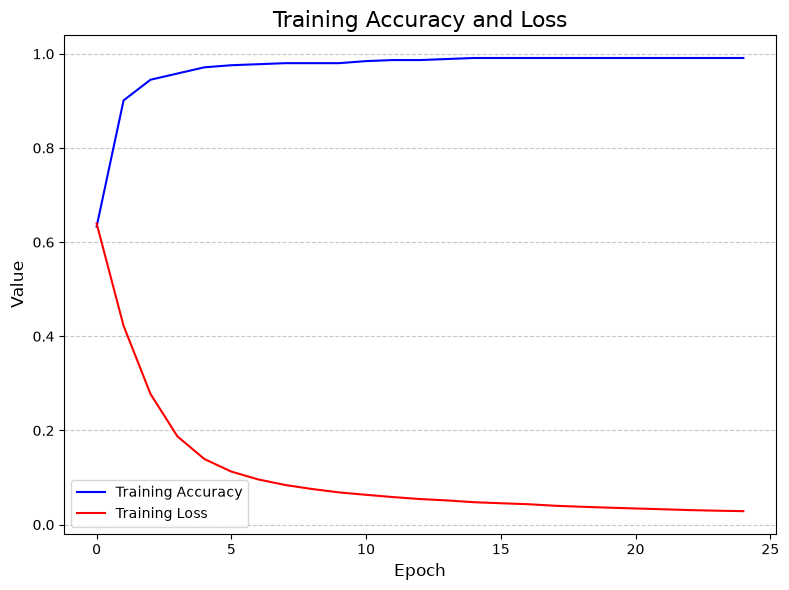

In [33]:
plt.figure(figsize=(8, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy", color="blue")
plt.plot(history.history["loss"], label="Training Loss", color="red")

plt.title("Training Accuracy and Loss", fontsize=16)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha= 0.7)
plt.tight_layout()
plt.legend()

plt.show()